In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import json 
import numpy as np
import seaborn as sns

# Preliminary Analysis

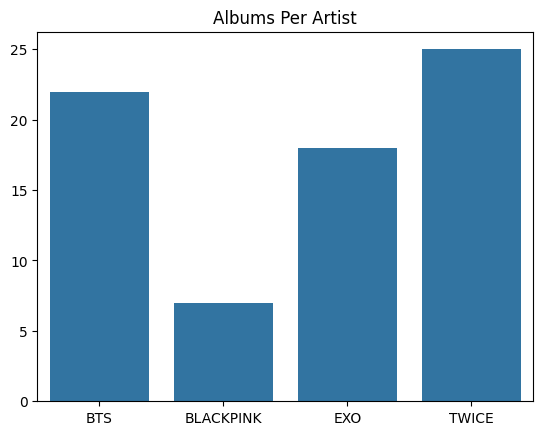

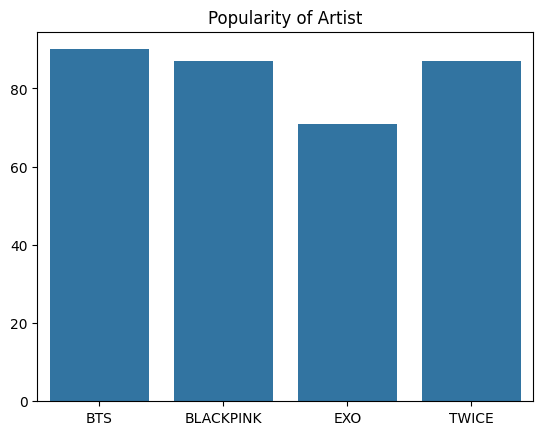

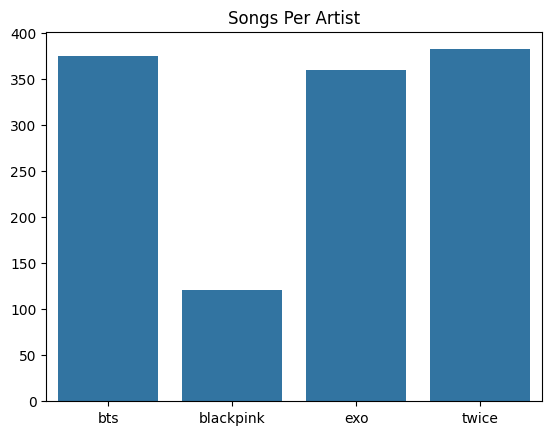

In [ ]:
artist = 'bts'
artists = ['bts','blackpink','exo','twice']
all_artists_albums = {}
all_artists_popularity = {}
all_artists_songs = {}


for artist in artists:
    # getting albums data
    spotify_file = open(f'raw_data/artist_data/{artist}_data.json', 'r')
    spotify_data = json.load(spotify_file)
    all_artists_albums[artist.upper()] = len(spotify_data['albums'])
    all_artists_popularity[artist.upper()] = spotify_data['popularity']

sns.barplot(data=all_artists_albums)
plt.title('Albums Per Artist')
plt.show()

sns.barplot(data=all_artists_popularity)
plt.title('Popularity of Artist')
plt.show()


for artist in artists:
    songs_file = open(f'cleaned_data/artist_songs_data/{artist}_cleaned_songs.json', 'r')
    songs_data = json.load(songs_file)
    all_artists_songs[artist] = len(songs_data)

sns.barplot(data=all_artists_songs)
plt.title('Songs Per Artist')
plt.show()


# Scatter Plot: Release Date vs Language Composition (cld2)

In [713]:
def ordinal2date(x, pos):
    if x>=1:
        return pd.Timestamp.fromordinal(int(x)).strftime('%Y-%m-%d')
    return ''

In [1]:
def lang_comp_plot(artist):

    # getting the date series from the genius songs data file 

    artist_file = open(f'cleaned_data/artist_songs_data/{artist}_cleaned_songs.json', 'r')
    artist_data = json.load(artist_file)

    for index, datapoint in enumerate(artist_data):
        if (datapoint['missing_date_component']):
            artist_data[index]['release_date_string'] = '1899-01-01'
        else:
            artist_data[index]['release_date_string'] = f'{datapoint['release_date_components']['year']}-{datapoint['release_date_components']['month']:02d}-{datapoint['release_date_components']['day']:02d}'

    date_df = pd.DataFrame(artist_data)
    date_series = pd.Series(date_df['release_date_string'])

    date_df['date'] = pd.to_datetime(date_df['release_date_string'])
    date_series = pd.Series(date_df['date'], name='Date')
    date_df = pd.DataFrame({'date':date_series})
    date_df['date_ordinal'] = date_df['date'].apply(lambda x: x.toordinal())


    ################################################

    # getting and expanding the language percent of each song 

    file = open(f'processed_data/cld2/lang_percent/{artist}_percent_cld2.json','r')
    songs = json.load(file)

    for index, song in enumerate(songs): 
        songs[index]['ENGLISH'] = 0
        songs[index]['KOREAN'] = 0
        songs[index]['JAPANESE'] = 0
        songs[index]['CHINESE'] = 0
        songs[index]['OTHERS/UNKNOWN'] = 0
        sum = 0
        for lang in song['lang_percent']:
            if lang == 'ENGLISH' or lang == 'KOREAN' or lang == 'JAPANESE' or lang == 'CHINESE' or lang == 'CHINESET':
                if lang == 'CHINESE' or lang == 'CHINESET':
                    songs[index]['CHINESE'] += songs[index]['lang_percent'][lang]
                else:
                    songs[index][lang] = songs[index]['lang_percent'][lang]
                sum += songs[index]['lang_percent'][lang]
        songs[index]['OTHERS/UNKNOWN'] = 1-sum
        # print()

    songs_df = pd.DataFrame(songs)
    songs_df = songs_df.drop(['lang_percent', 'lang_comp_sorted'], axis=1)


    ################################################

    # creating combined dataframe with date and individual language composition 
    joined_df = date_df.join(songs_df)


    # dropping datapoints with insufficient date information 
    condition = joined_df['date'] == pd.to_datetime('1899-01-01')

    drop_indices = joined_df[condition].index
    joined_df.drop(drop_indices,inplace=True)


    ################################################


    fig, ax = plt.subplots(figsize=(20,10))
    sns.regplot(data=joined_df,x='date_ordinal',y='ENGLISH', scatter_kws={'label':'English'}, ax=ax, label='English', color='#ef476f')
    sns.regplot(data=joined_df,x='date_ordinal',y='KOREAN', ax=ax, label='Korean', color='#118ab2')
    sns.regplot(data=joined_df,x='date_ordinal',y='JAPANESE', ax=ax, label='Japanese', color='#ffd166')
    sns.regplot(data=joined_df,x='date_ordinal',y='OTHERS/UNKNOWN', ax=ax, label='Others/Unknown', color='#83c5be')

    date_format = matplotlib.dates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(ordinal2date))
    ax.set_xlabel('Date')
    ax.set_ylabel('Language Composition Percentage')
    ax.legend()
    ax.grid(True)
    plt.title(f'Language Composition of Songs by {artist.upper()} Overtime', weight='bold')
    plt.tight_layout()
    plt.show()



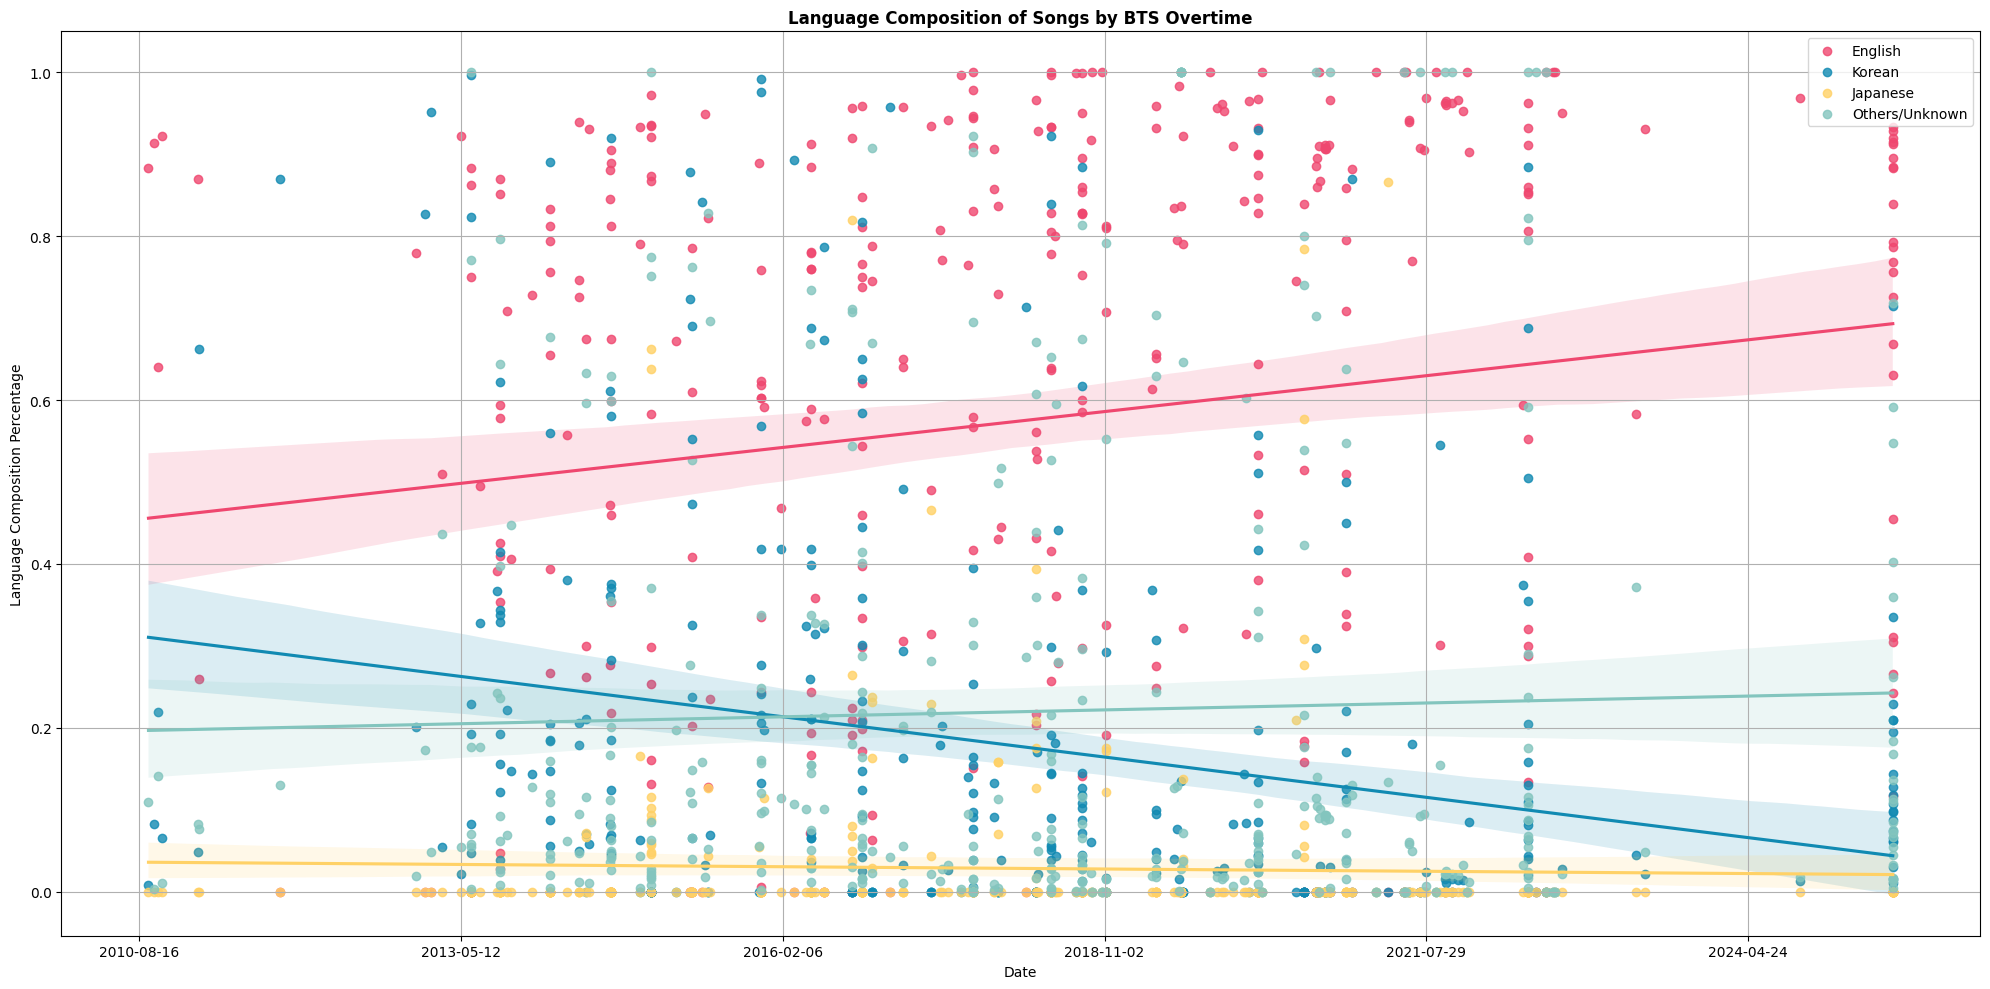

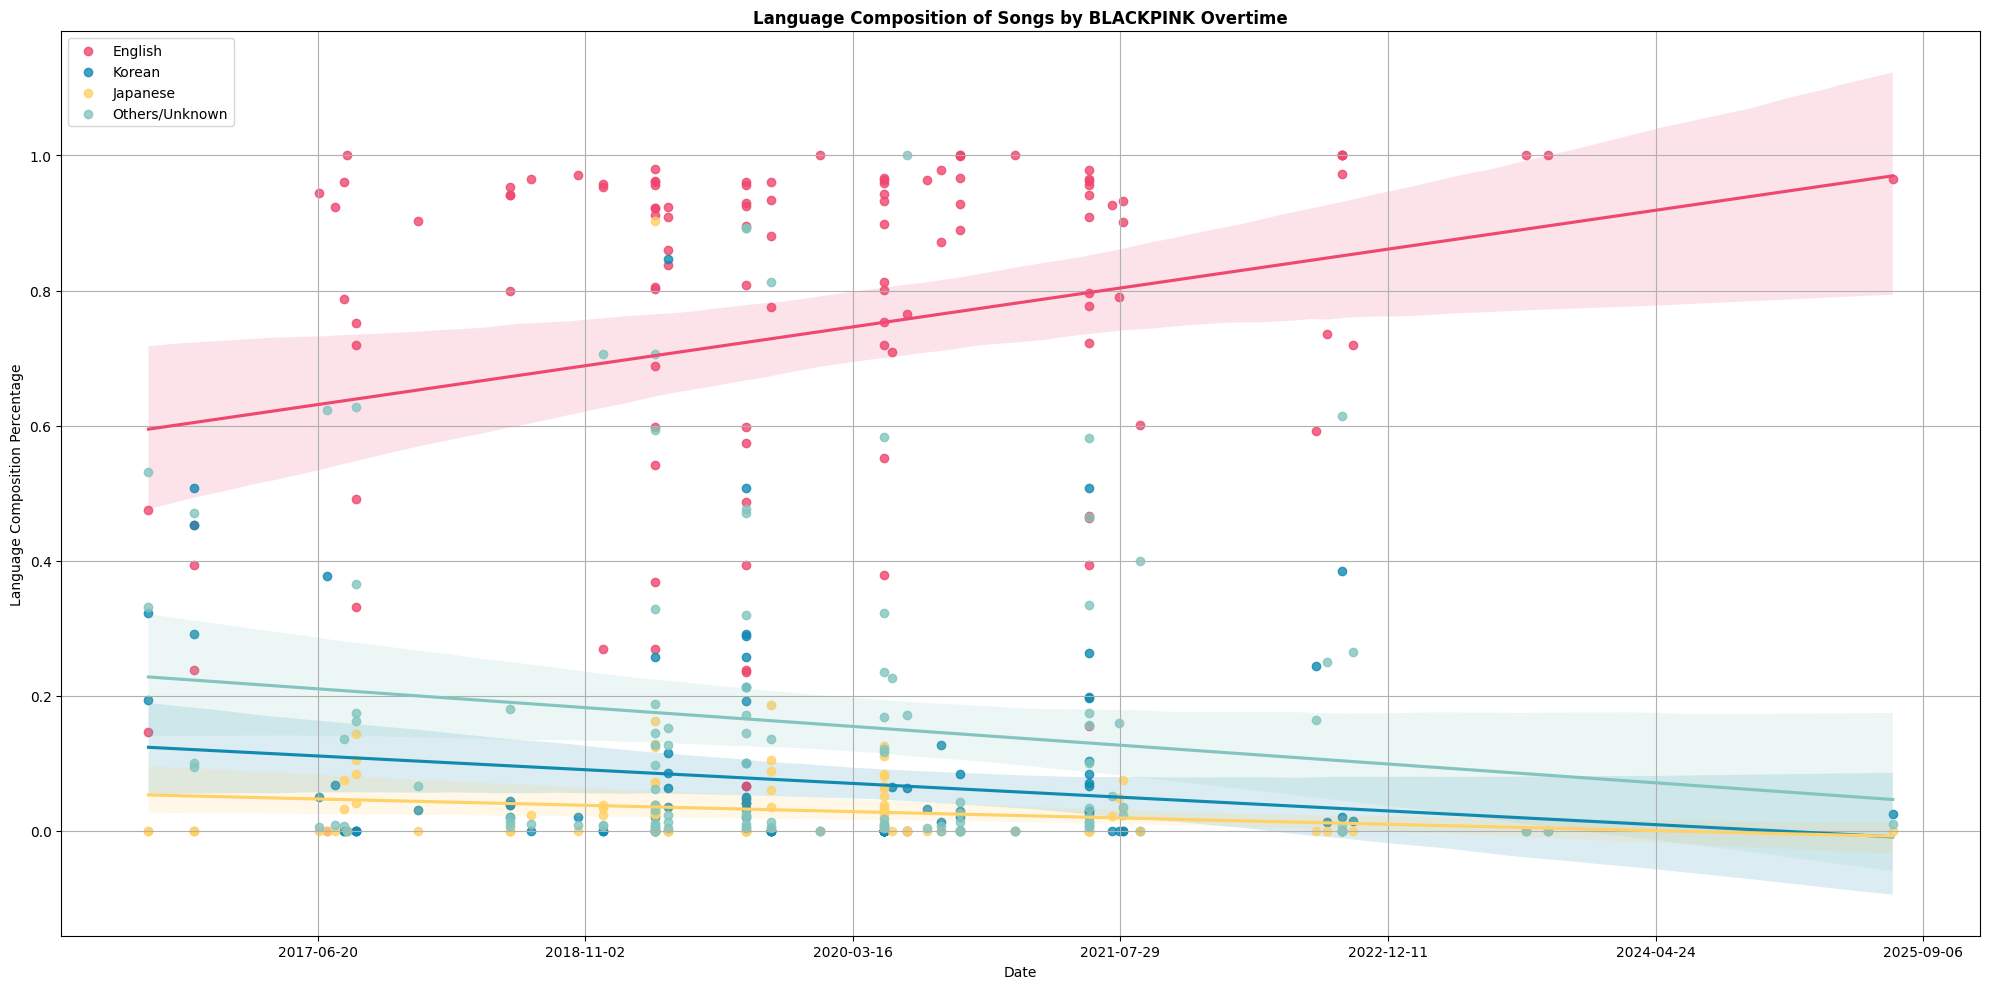

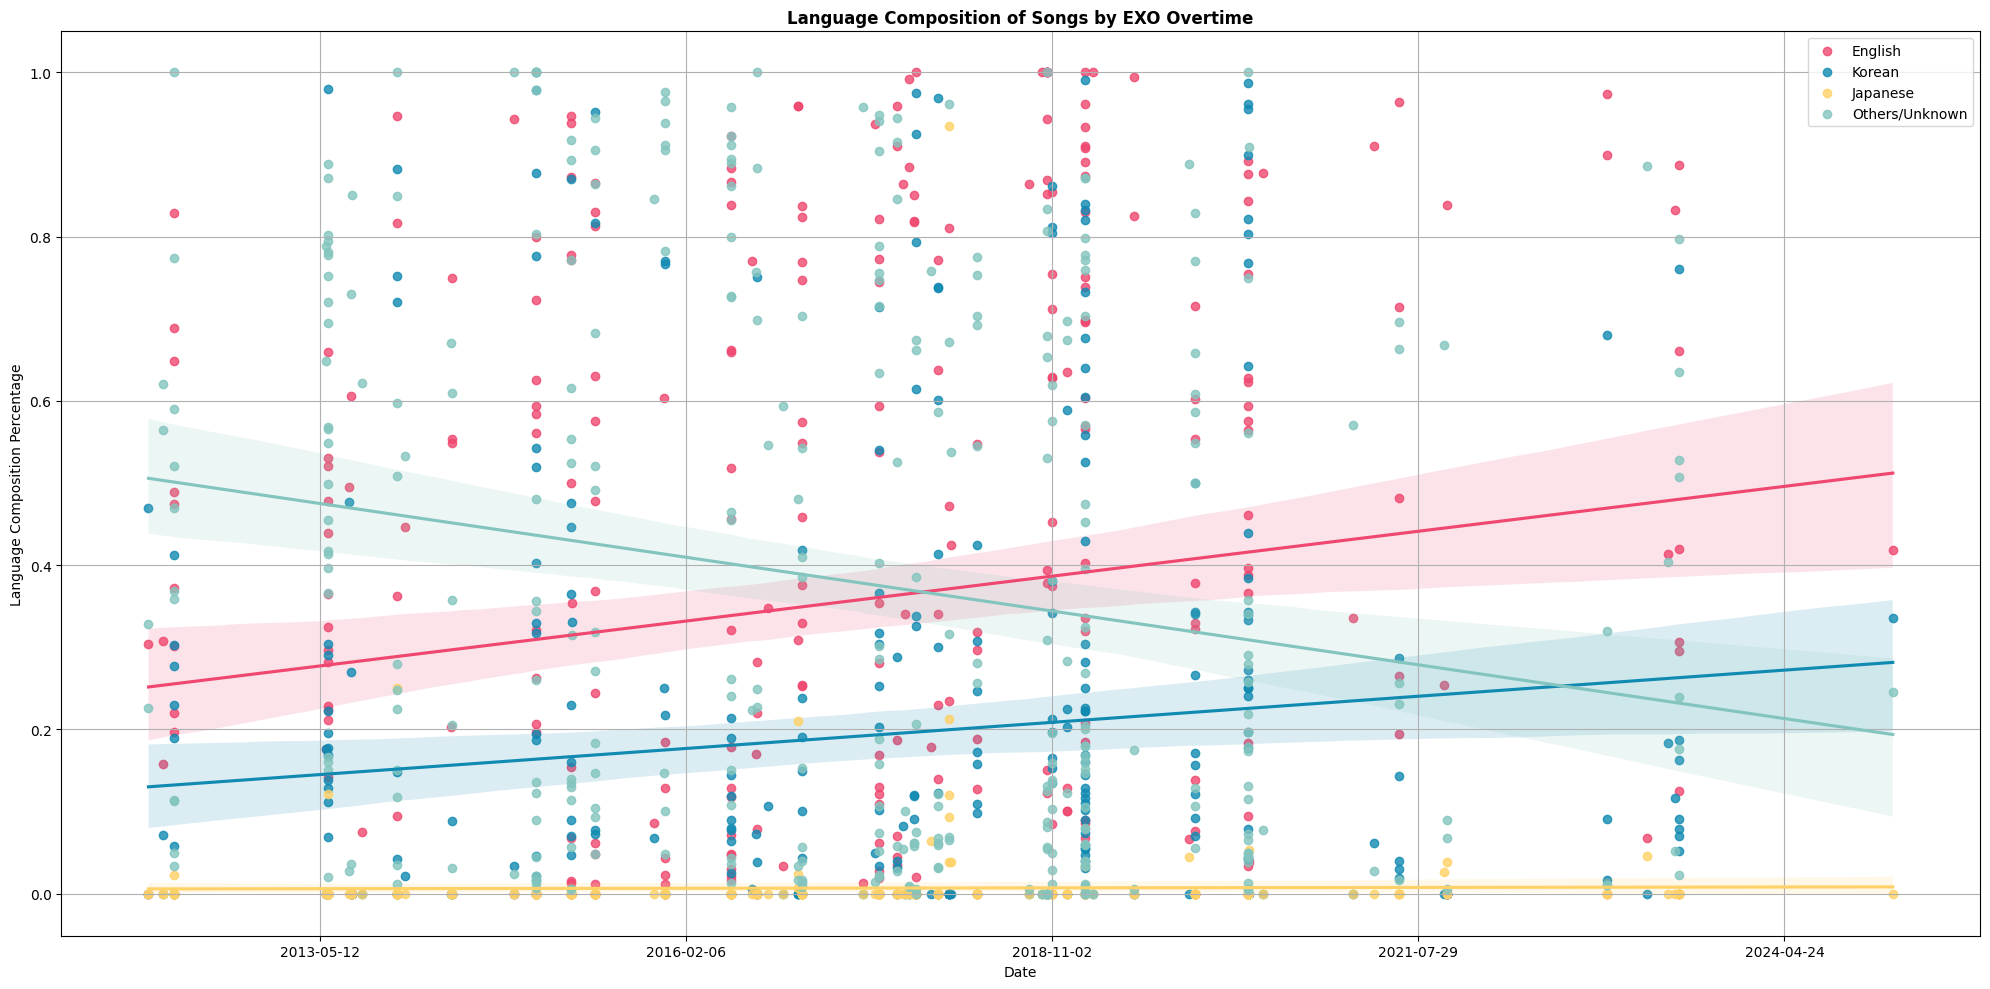

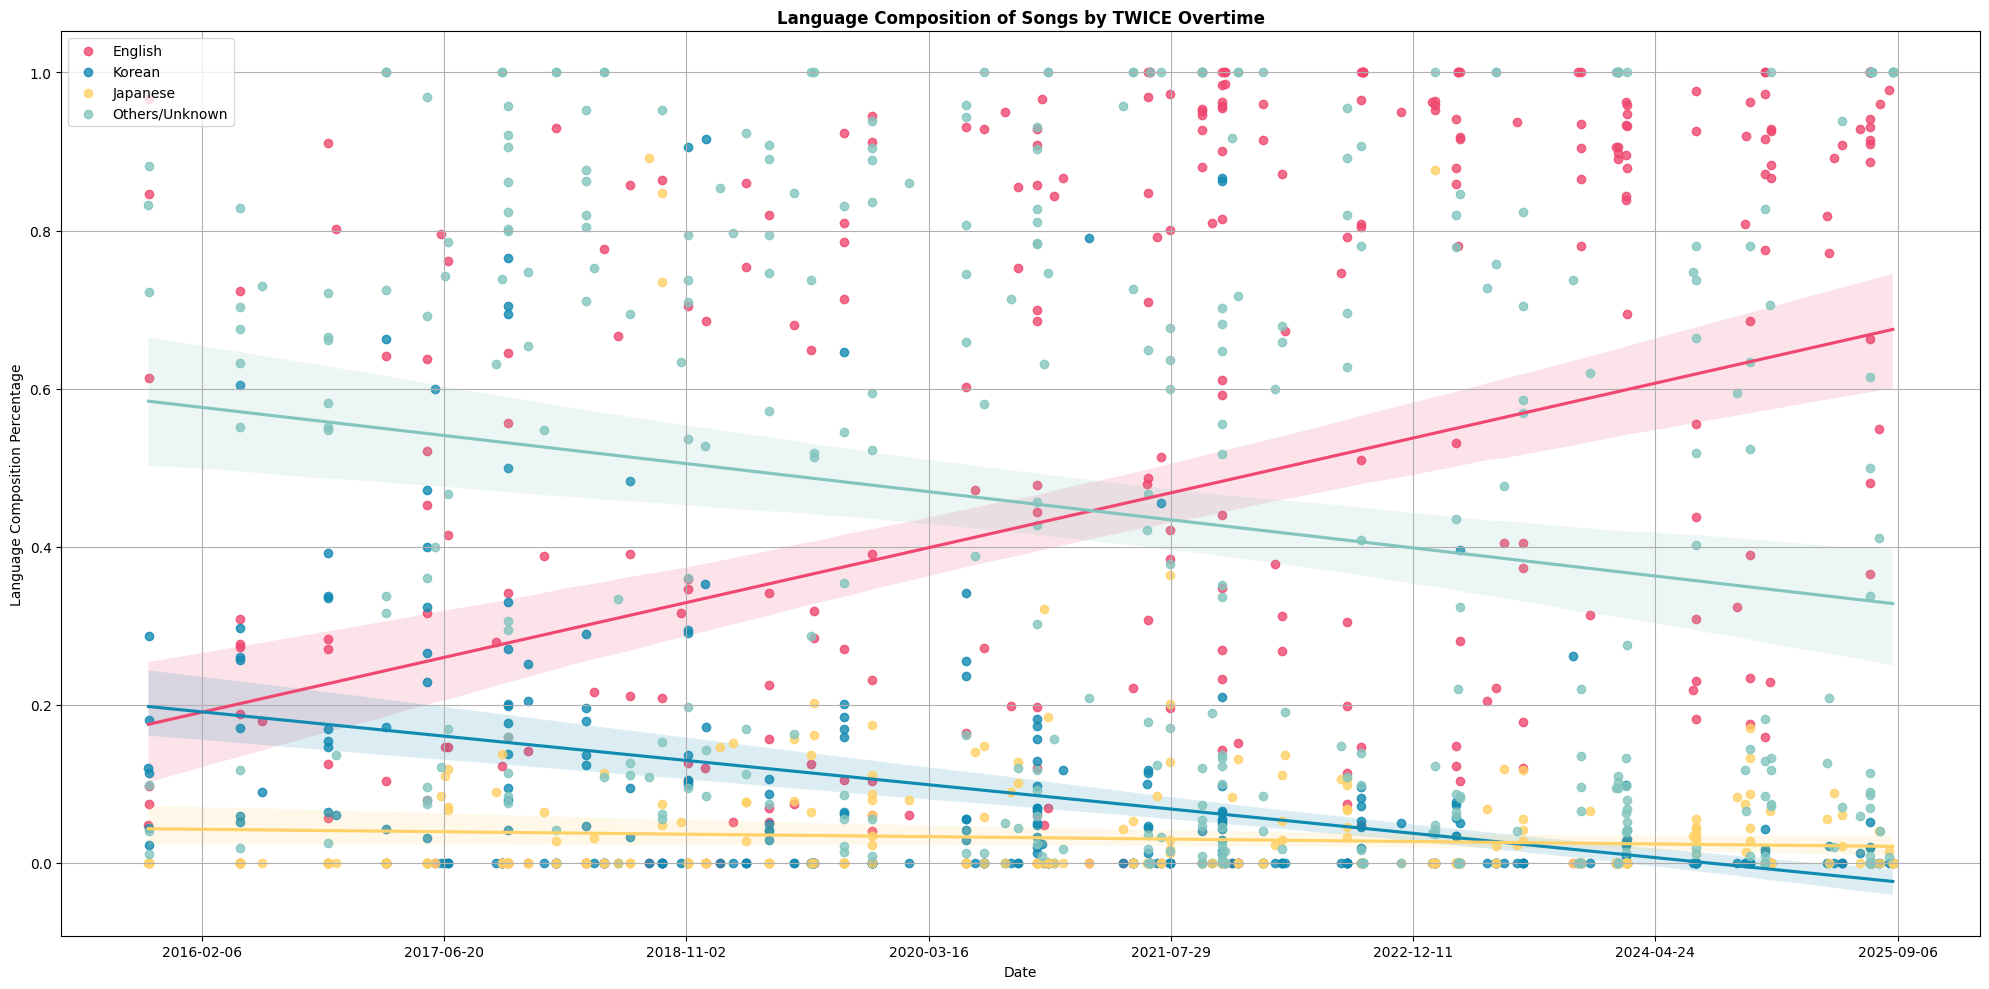

In [715]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    lang_comp_plot(artist)

# Frequency of Billboard Global 200 Songs Language Composition

In [26]:
def billboard_lang_comp_hist(artist):

    billboard_file = open(f'processed_data/billboard_lang_percent/{artist}_billboard_lang_percent.json')
    billboard_data = json.load(billboard_file)

    billboard_df = pd.DataFrame(billboard_data['billboard_data'])

    langs_df = billboard_df['lang_percent'].apply(pd.Series)

    billboard_df = billboard_df.join(langs_df)

    condition = billboard_df['UNKNOWN'] == 1

    drop_indices = billboard_df[condition].index
    billboard_df.drop(drop_indices,inplace=True)

    fig, ax = plt.subplots(figsize=(10,6))

    if 'ENGLISH' in billboard_df:
        sns.histplot(data=billboard_df, x='ENGLISH', kde=True, label='English', color='#ef476f', bins=5, ax=ax)

    if 'KOREAN' in billboard_df:
        sns.histplot(data=billboard_df, x='KOREAN', kde=True, label='Korean', color='#118ab2', bins=5, ax=ax)

    if 'JAPANESE' in billboard_df:
        sns.histplot(data=billboard_df, x='JAPANESE', kde=True, label='Japanese', color='#ffd166', bins=5, ax=ax)

    plt.title(f'Frequency of Language Percentage of Billboard Global 200 Songs By {artist.upper()}', weight='bold')
    plt.legend()
    plt.grid(True)
    plt.show()



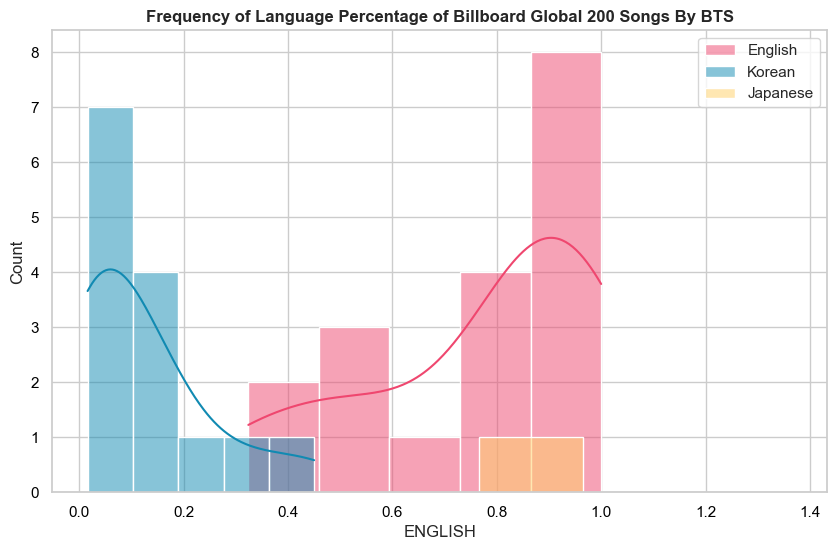

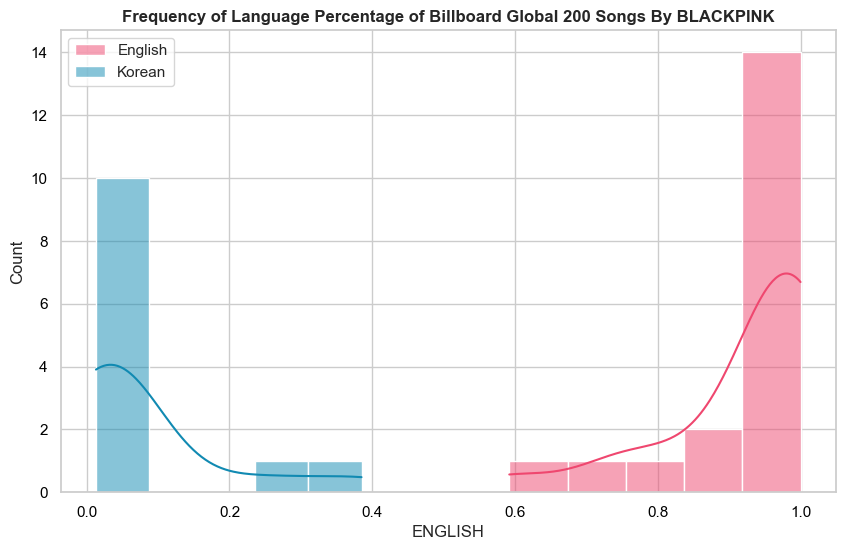

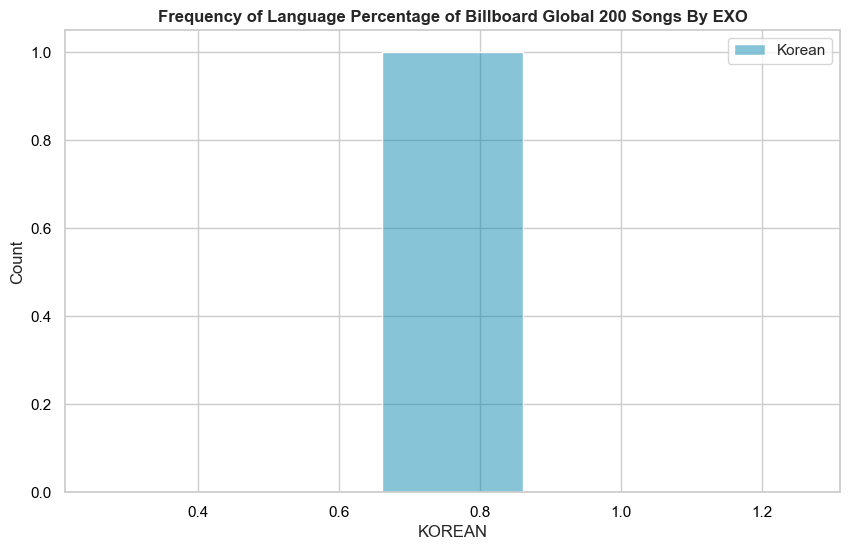

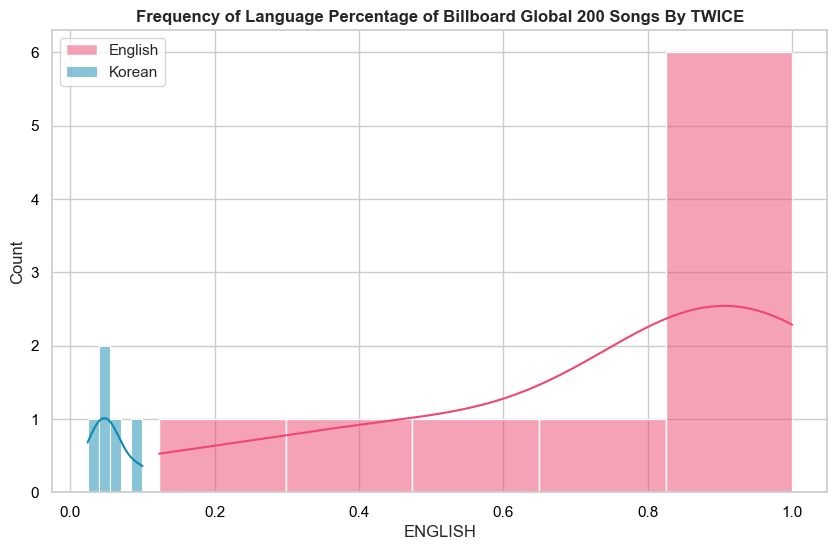

In [27]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    billboard_lang_comp_hist(artist)

# Spotify Top Tracks' Language Composition

In [740]:
def tracks_lang_comp(artist):

    # getting albums data
    spotify_file = open(f'processed_data/spotify_lang_percent/{artist}_spotify_lang_percent.json', 'r')
    spotify_data = json.load(spotify_file)

    spotify_df = pd.DataFrame(spotify_data['top_tracks'])

    langs_df = spotify_df['lang_percent'].apply(pd.Series)


    spotify_df = spotify_df.join(langs_df)

    for col in spotify_df:
        spotify_df[col] = spotify_df[col].fillna(0)


    condition = spotify_df['UNKNOWN'] == 1

    drop_indices = spotify_df[condition].index
    spotify_df.drop(drop_indices,inplace=True)


    spotify_df['date'] = pd.to_datetime(spotify_df['release_date'])
    spotify_df['date_ordinal'] = spotify_df['date'].apply(lambda x: x.toordinal())


    fig, ax = plt.subplots(figsize=(20,10))
    sns.regplot(data=spotify_df,x='date_ordinal',y='ENGLISH', scatter_kws={'label':'English'}, ax=ax, label='English', color='#ef476f')
    sns.regplot(data=spotify_df,x='date_ordinal',y='KOREAN', scatter_kws={'label':'Korean'}, ax=ax, label='Korean', color='#118ab2')
    sns.regplot(data=spotify_df,x='date_ordinal',y='UNKNOWN', scatter_kws={'label':'Unknown'}, ax=ax, label='Unknown', color='#83c5be')
    # sns.regplot(data=spotify_df,x='date_ordinal',y='JAPANESE', scatter_kws={'label':'Japanese'}, ax=ax, label='Japanese', ci=None, color='#ffd166')


    date_format = matplotlib.dates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(ordinal2date))
    ax.set_xlabel('Date')
    ax.set_ylabel('Language Composition Percentage')
    ax.legend()
    ax.grid(True)
    plt.title(f'Language Composition of Top Songs by {artist.upper()} Overtime', weight='bold')
    plt.tight_layout()
    plt.show()
 


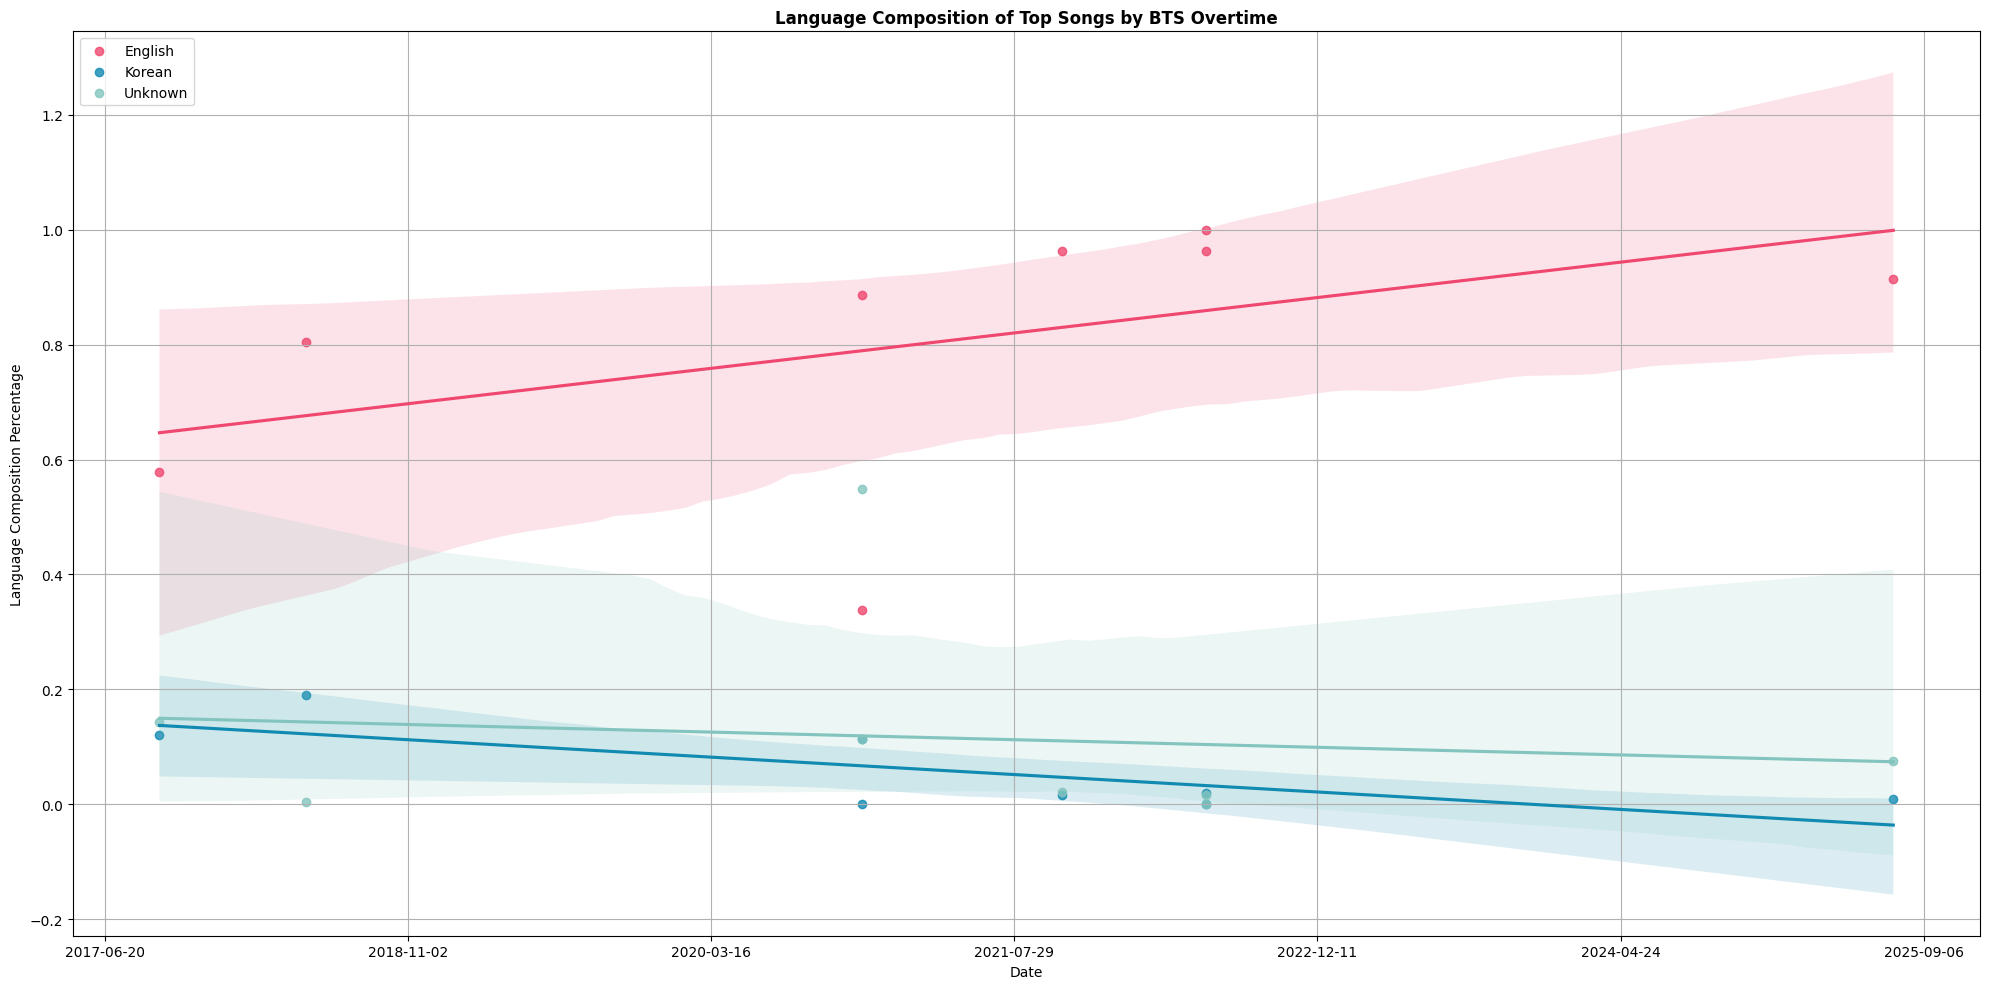

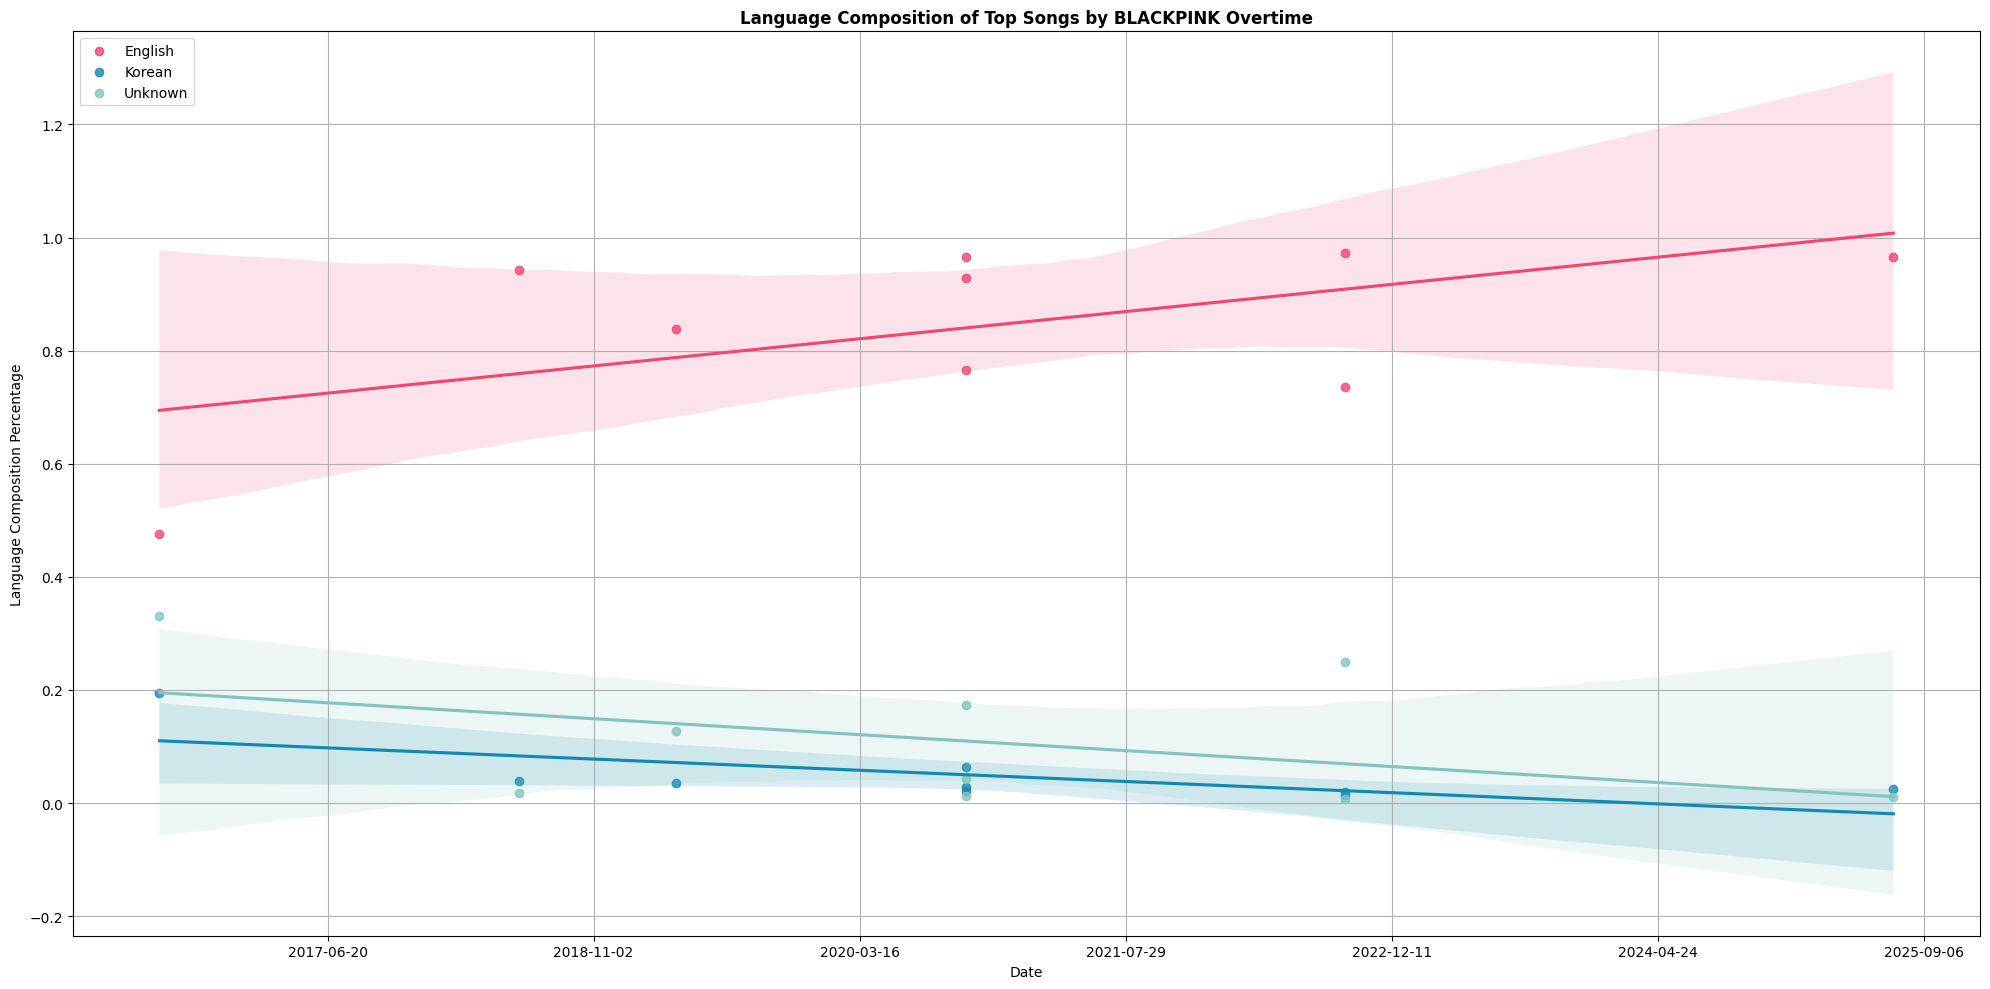

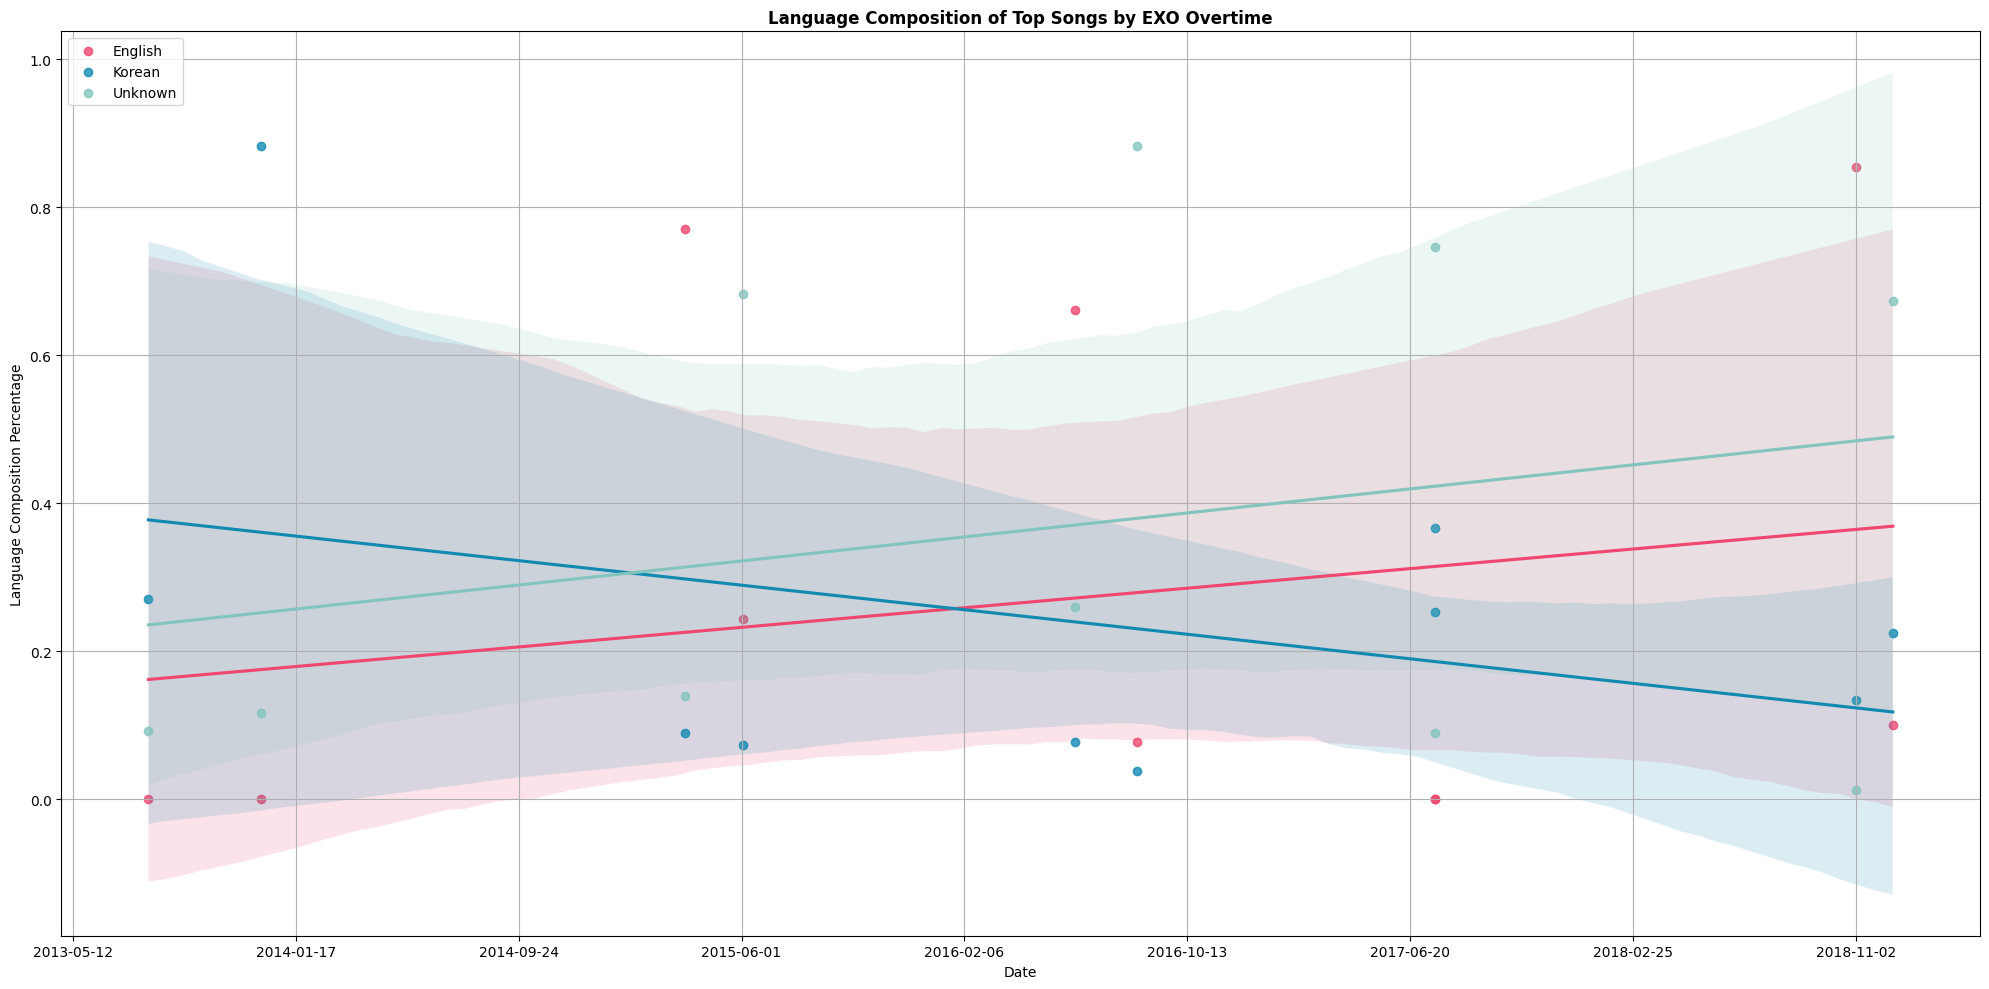

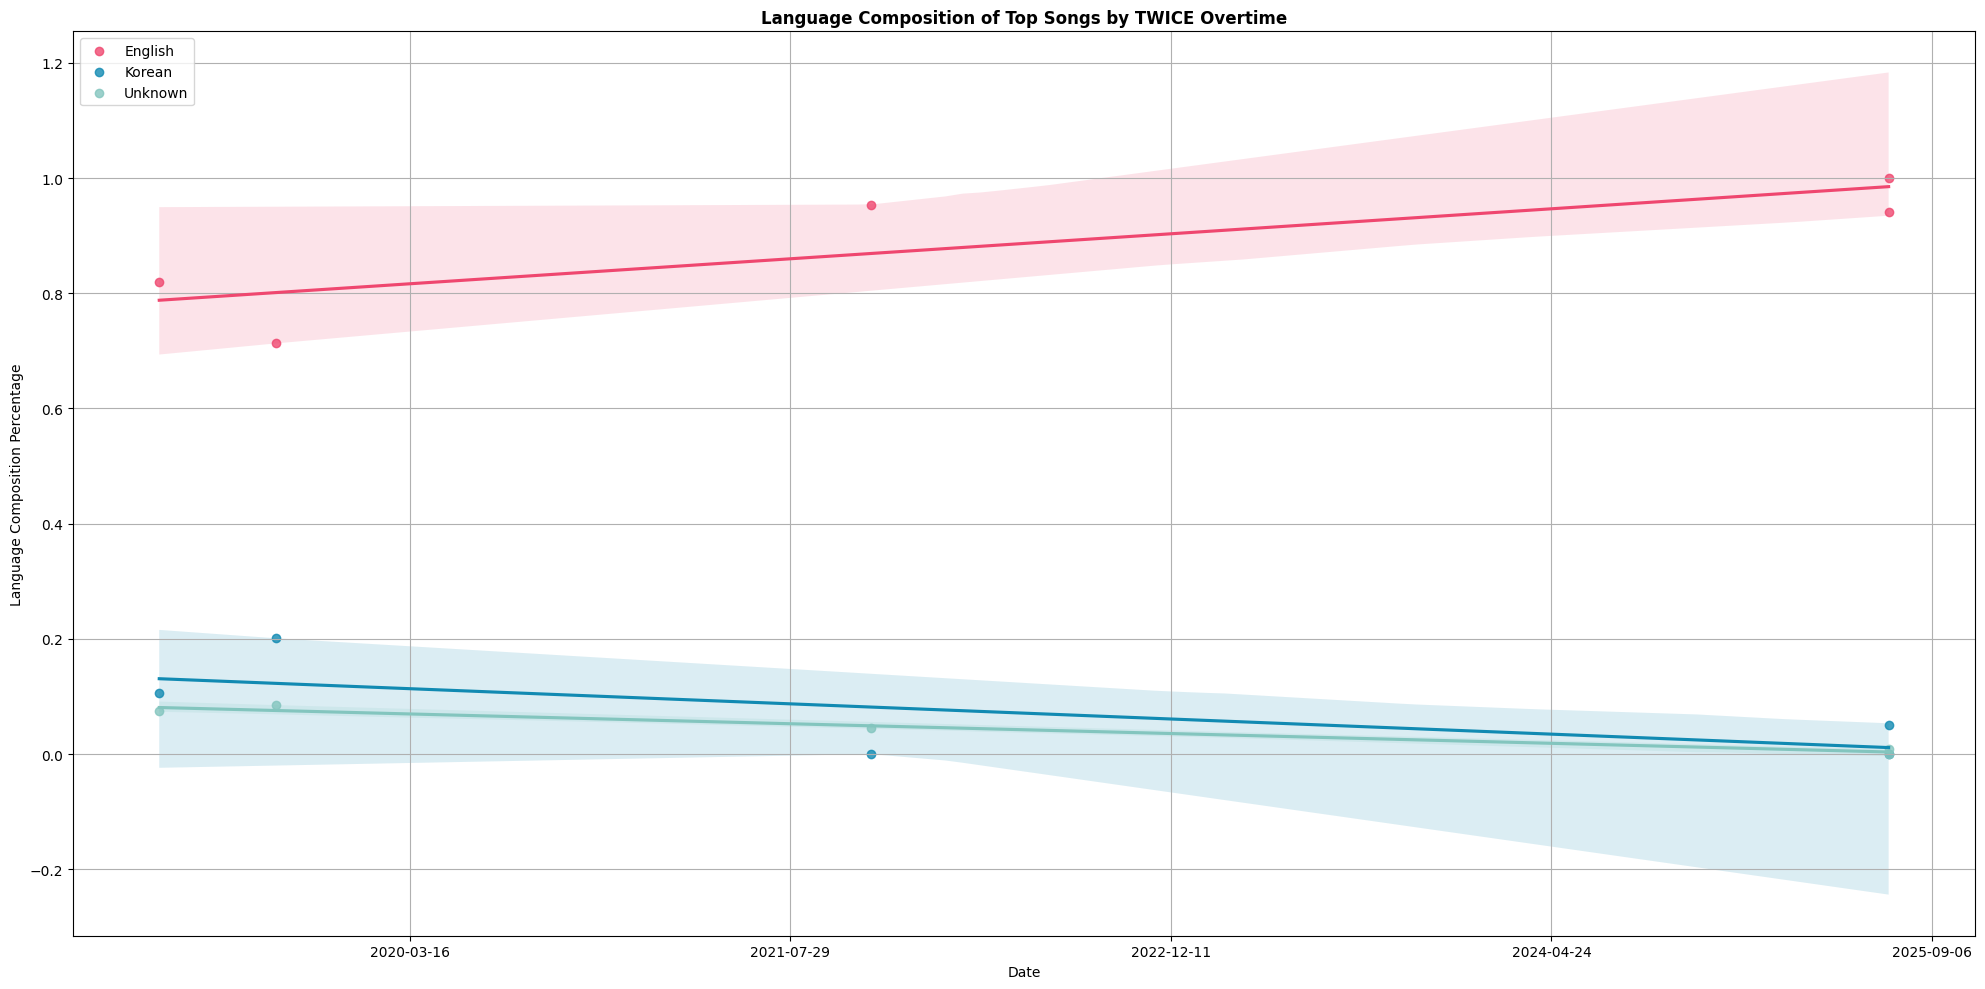

In [739]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    tracks_lang_comp(artist)

In [750]:

def tracks_lang_comp_line(artist):

    # getting albums data
    spotify_file = open(f'processed_data/spotify_lang_percent/{artist}_spotify_lang_percent.json', 'r')
    spotify_data = json.load(spotify_file)

    spotify_df = pd.DataFrame(spotify_data['top_tracks'])

    langs_df = spotify_df['lang_percent'].apply(pd.Series)


    spotify_df = spotify_df.join(langs_df)

    for col in spotify_df:
        spotify_df[col] = spotify_df[col].fillna(0)


    condition = spotify_df['UNKNOWN'] == 1

    drop_indices = spotify_df[condition].index
    spotify_df.drop(drop_indices,inplace=True)


    spotify_df['date'] = pd.to_datetime(spotify_df['release_date'])
    spotify_df['date_ordinal'] = spotify_df['date'].apply(lambda x: x.toordinal())


    fig, ax = plt.subplots(figsize=(20,10))
    sns.lineplot(data=spotify_df,x='date_ordinal',y='ENGLISH', ax=ax, label='English', color='#ef476f', errorbar=('ci', False))
    sns.lineplot(data=spotify_df,x='date_ordinal',y='KOREAN', ax=ax, label='Korean', color='#118ab2', errorbar=('ci', False))
    sns.lineplot(data=spotify_df,x='date_ordinal',y='UNKNOWN', ax=ax, label='Unknown', color='#83c5be', errorbar=('ci', False))
    # sns.regplot(data=spotify_df,x='date_ordinal',y='JAPANESE', scatter_kws={'label':'Japanese'}, ax=ax, label='Japanese', ci=None, color='#ffd166')


    date_format = matplotlib.dates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(ordinal2date))
    ax.set_xlabel('Date')
    ax.set_ylabel('Language Composition Percentage')
    ax.legend()
    ax.grid(True)
    plt.title(f'Language Composition of Top Songs by {artist.upper()} Overtime', weight='bold')
    plt.tight_layout()
    plt.show()



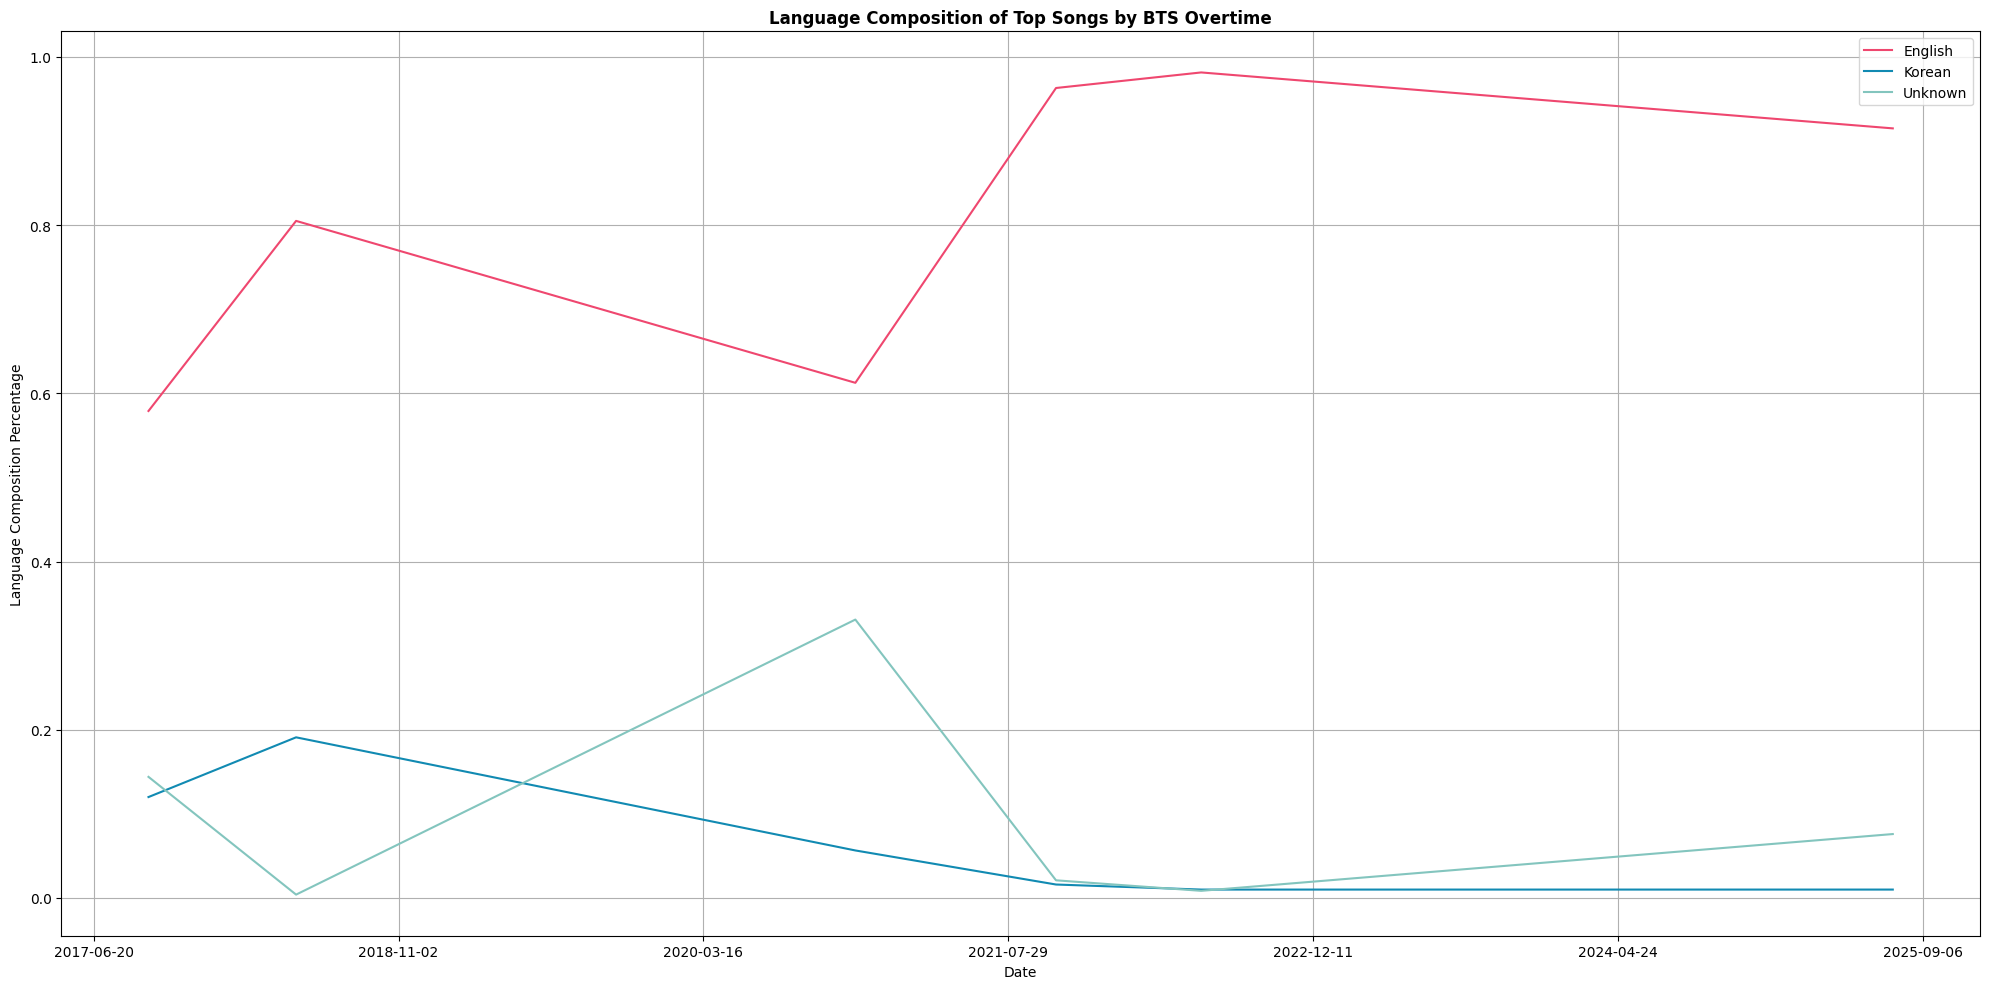

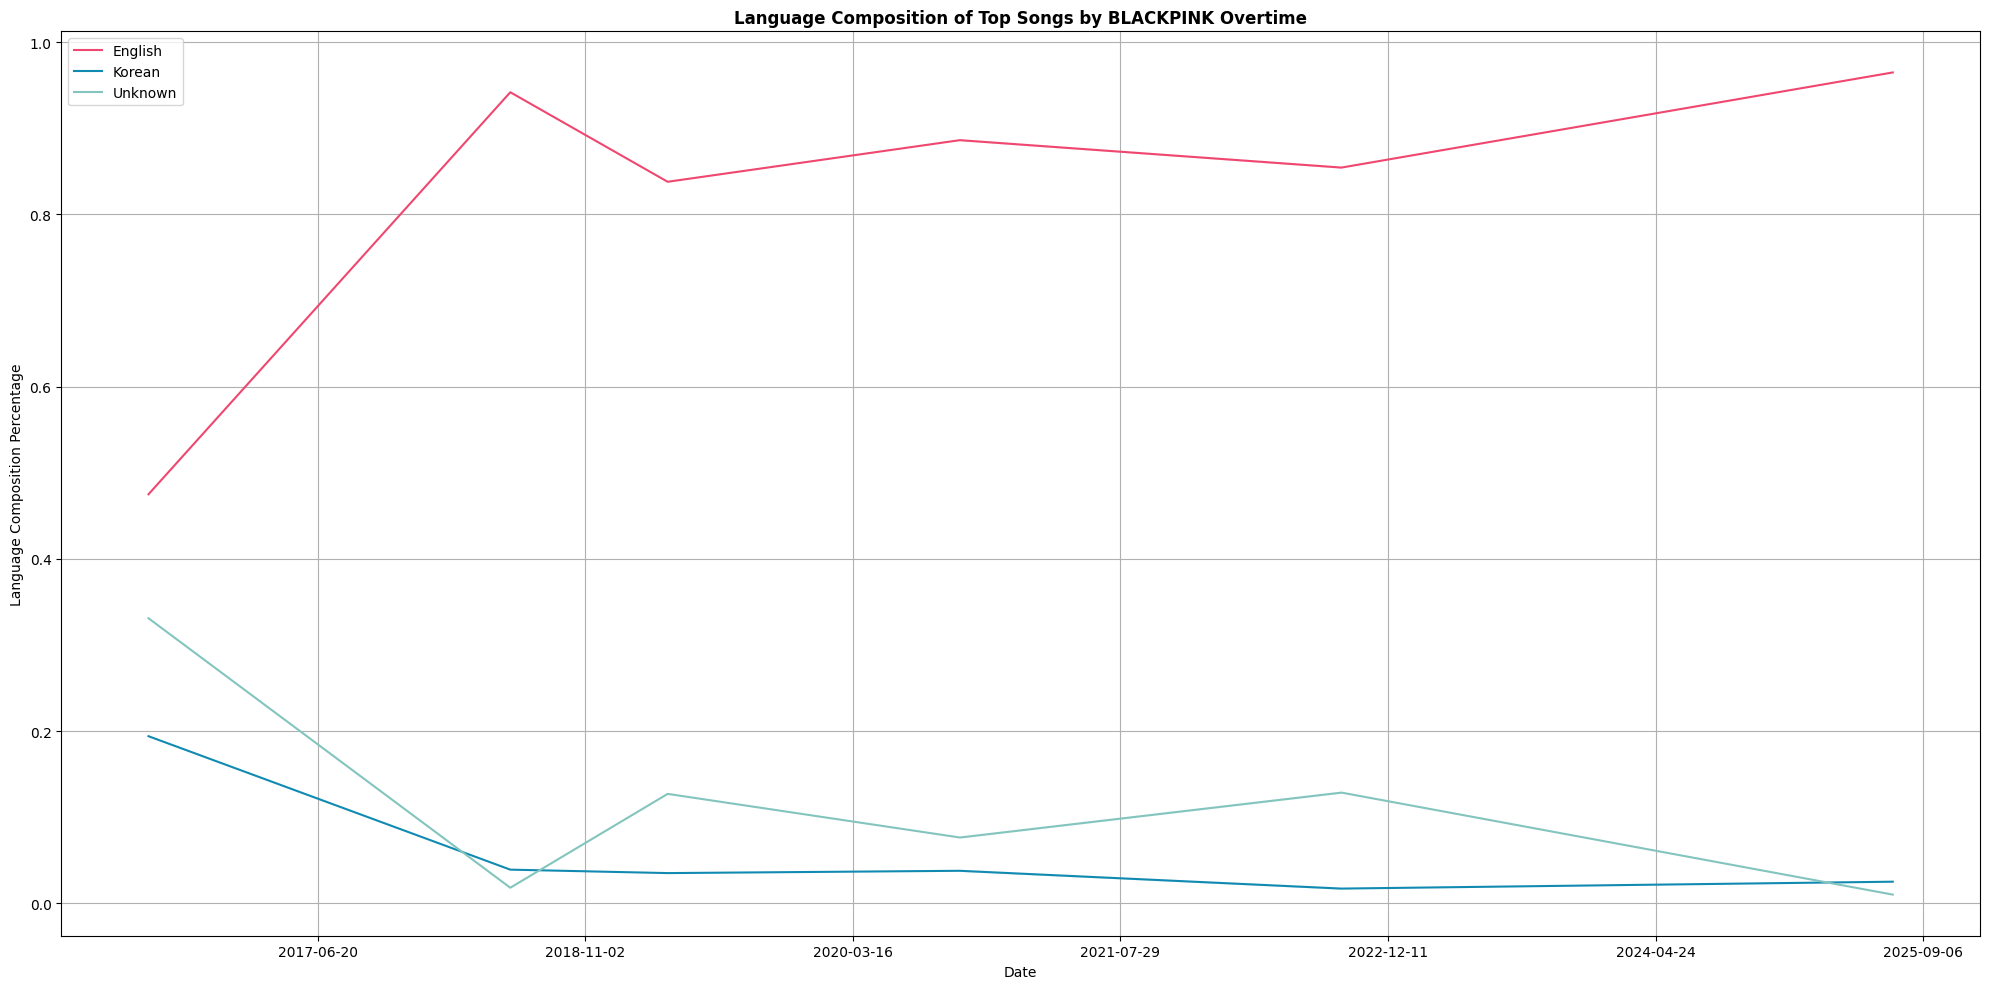

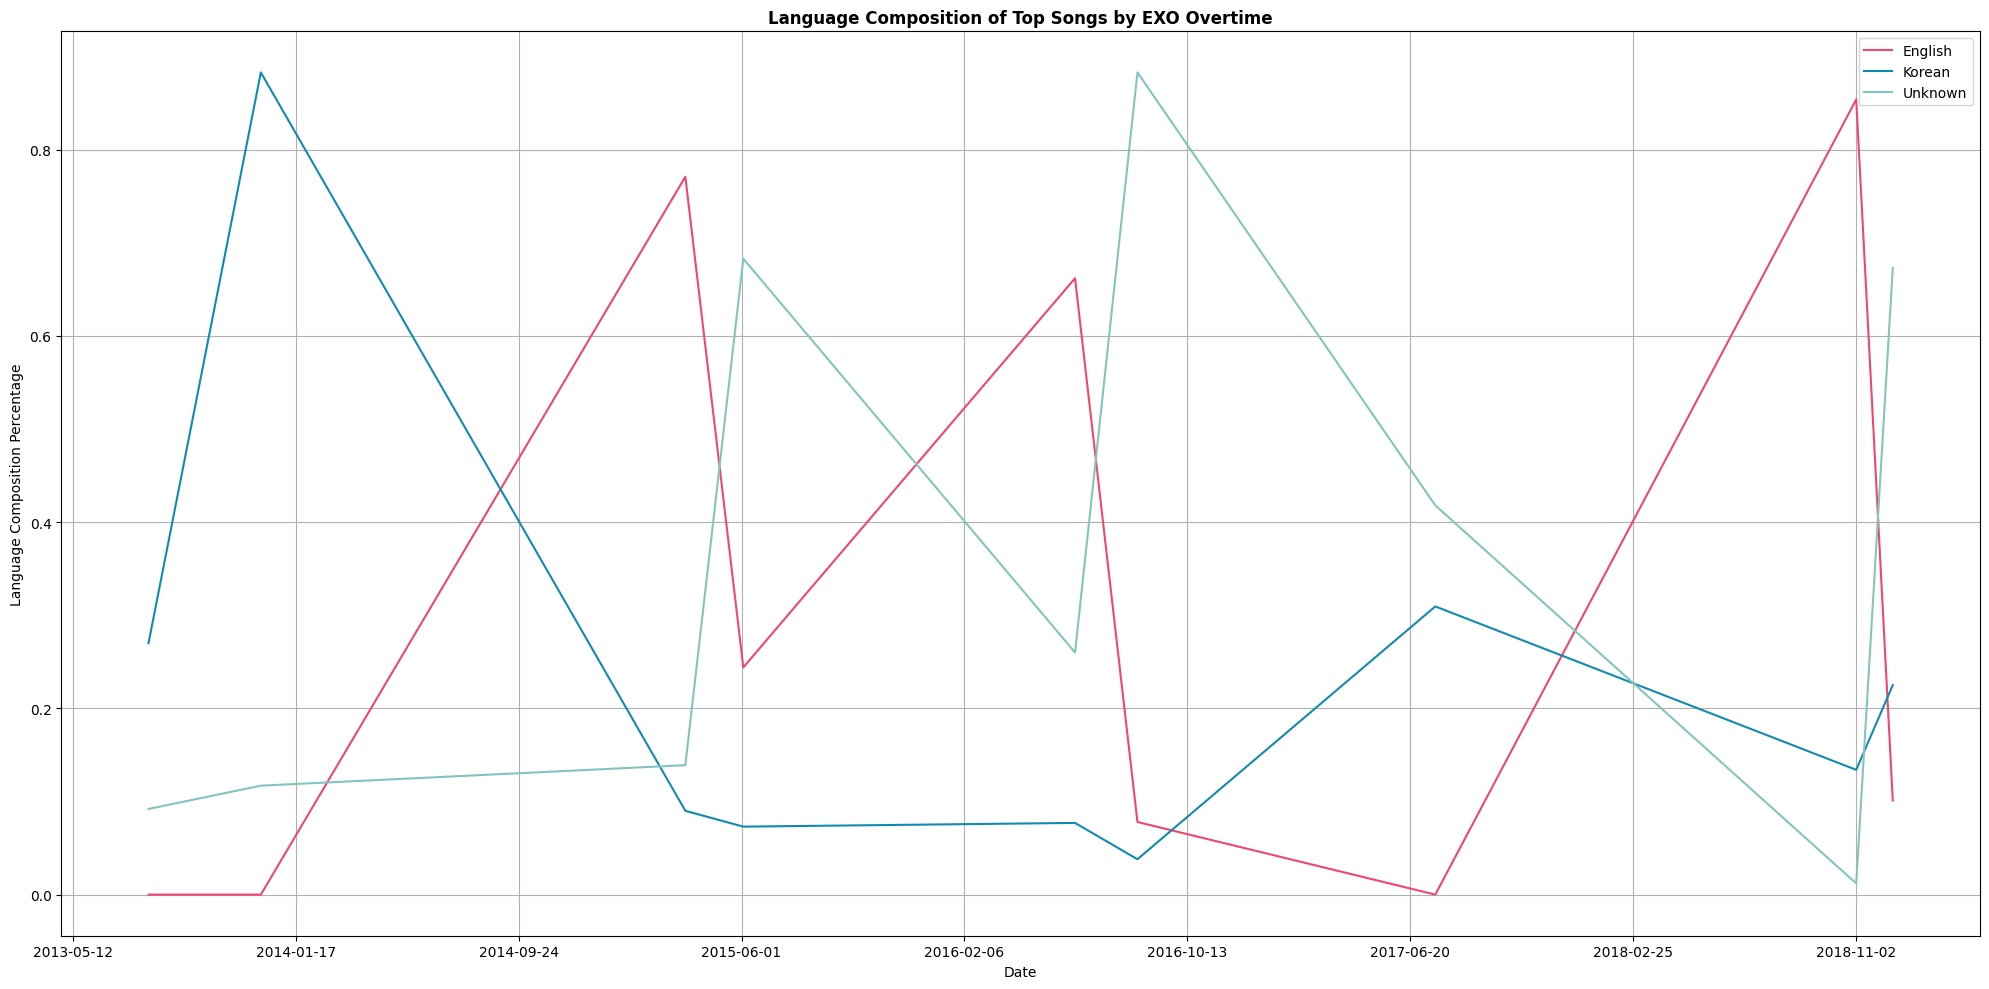

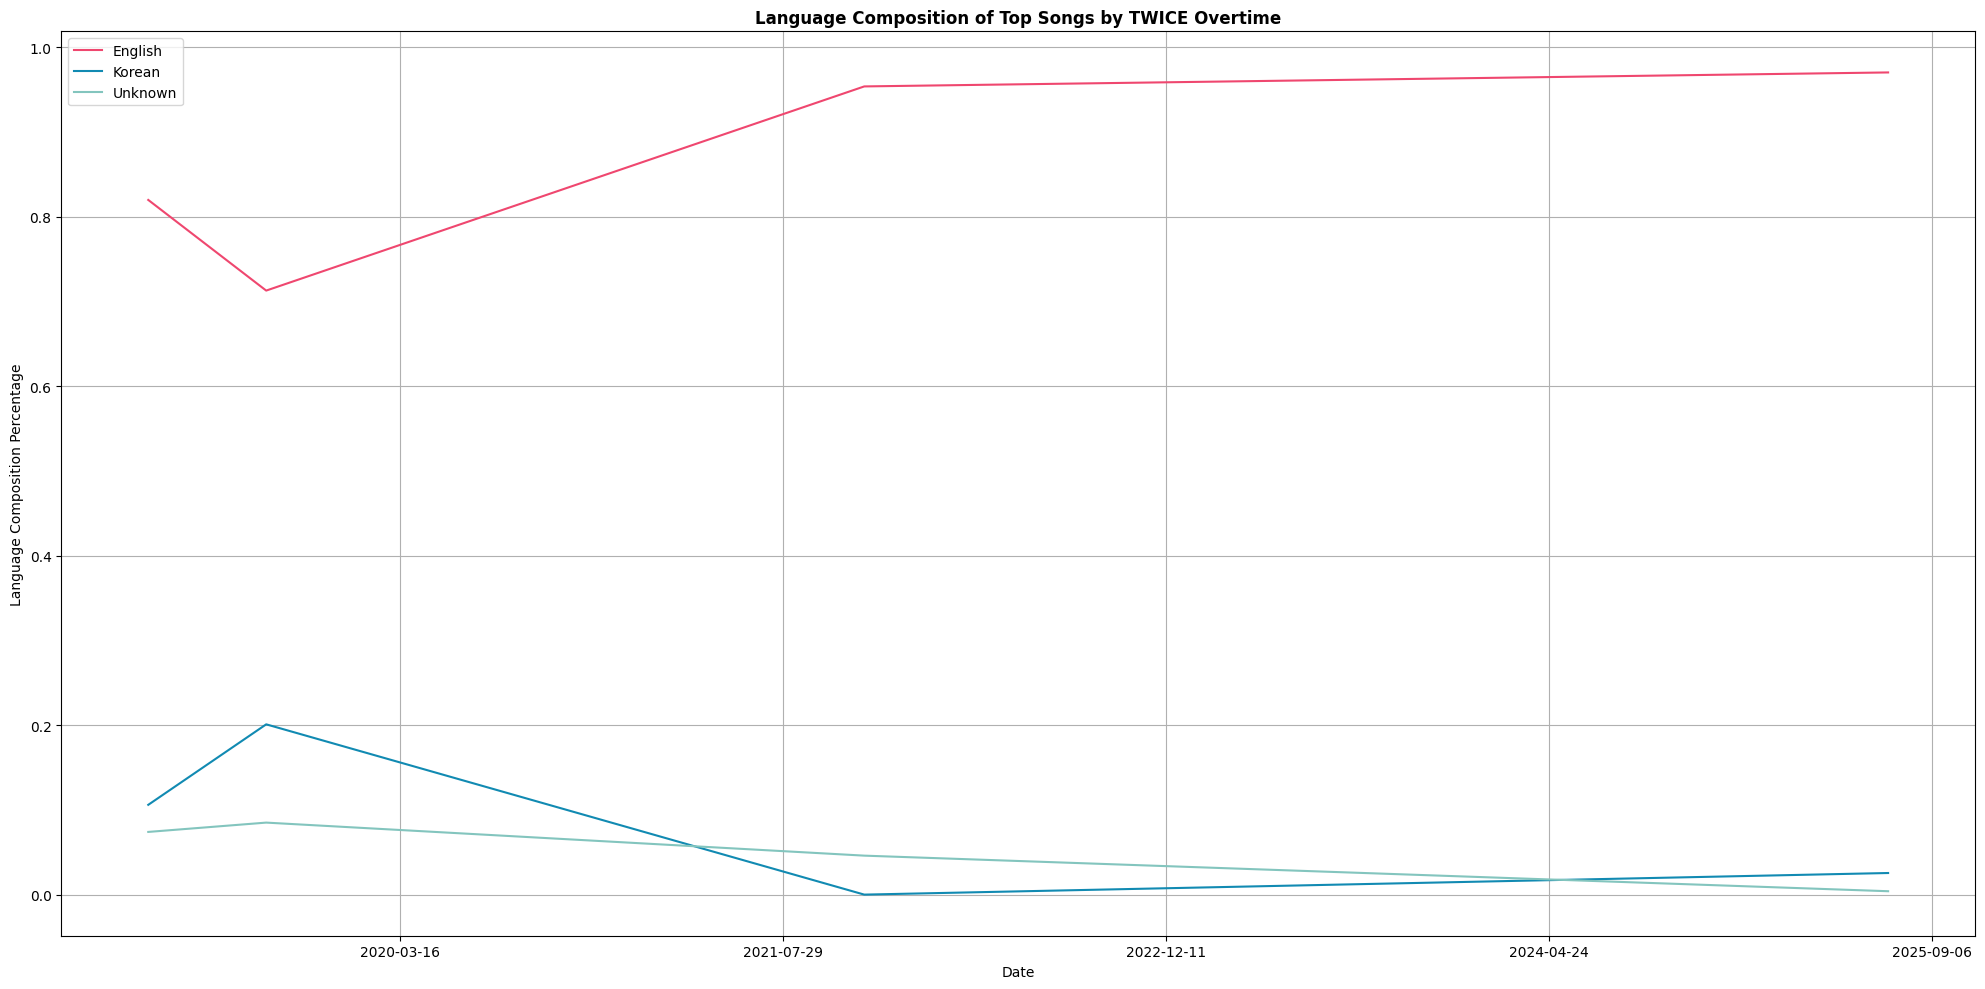

In [751]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    tracks_lang_comp_line(artist)

# Frequency of language composition

In [6]:
def lang_comp_hist(artist):

    songs_file = open(f'processed_data/cld2/lang_percent/{artist}_percent_cld2.json')
    songs_data = json.load(songs_file)

    songs_df = pd.DataFrame(songs_data)

    langs_df = songs_df['lang_percent'].apply(pd.Series)

    songs_df = songs_df.join(langs_df)

    for col in songs_df:
        songs_df[col] = songs_df[col].fillna(0)

    fig, ax = plt.subplots(figsize=(10,6))

    if 'ENGLISH' in songs_df:
        sns.histplot(data=songs_df, x='ENGLISH', kde=True, label='English', color='#ef476f', bins=5, ax=ax, edgecolor='black')

    if 'KOREAN' in songs_df:
        sns.histplot(data=songs_df, x='KOREAN', kde=True, label='Korean', color='#118ab2', bins=5, ax=ax, edgecolor='black')

    # if 'JAPANESE' in songs_df:
    #     sns.histplot(data=songs_df, x='JAPANESE', kde=False, label='Japanese', color='#ffd166', bins=5)

    ax.set_xlabel('Language')
    ax.set_ylabel('Frequency')
    # ax.set_facecolor('black')

    plt.title(f'Frequency of Language Percentage of All Songs By {artist.upper()}', weight='bold')
    plt.legend()

    # for saving in white 
    # ax.set_xlabel('Language', fontdict={'color': 'white'})
    # ax.set_ylabel('Frequency', fontdict={'color': 'white'})
    sns.set_theme(rc={'xtick.labelcolor': 'black', 'ytick.labelcolor': 'black'})
    sns.set_style("whitegrid")

    # plt.title(f'Frequency of Language Percentage of All Songs By {artist.upper()}', weight='bold', color='white')
    # plt.savefig(f'plots/songs_freq/{artist}.png', transparent=True)
    plt.show()


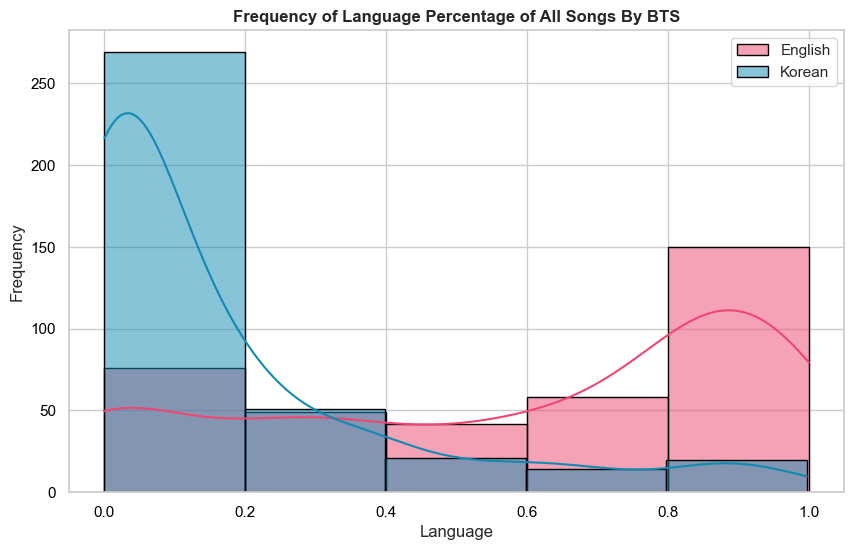

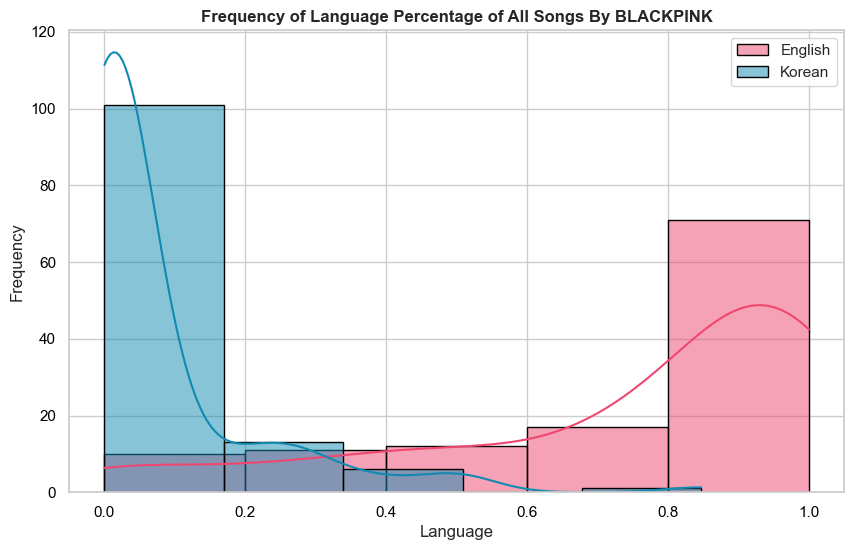

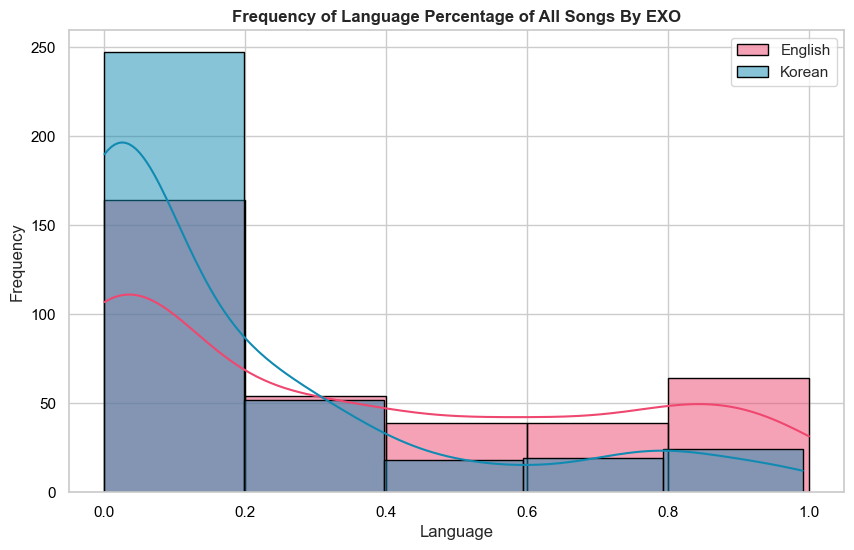

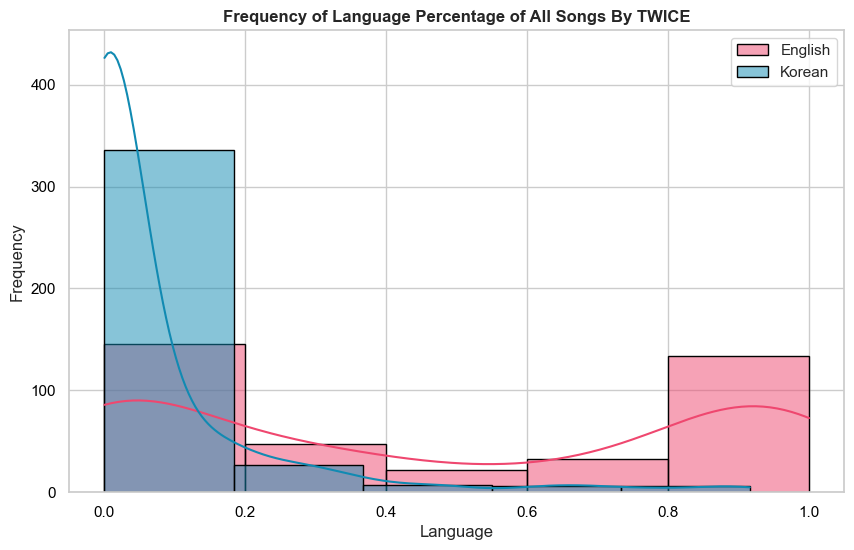

In [7]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    lang_comp_hist(artist)

# Frequency of Spotify Top Tracks Language Composition

In [22]:

def tracks_hist(artist):

    tracks_file = open(f'processed_data/spotify_lang_percent/{artist}_spotify_lang_percent.json')
    tracks_data = json.load(tracks_file)

    tracks_df = pd.DataFrame(tracks_data['top_tracks'])
    # tracks_df = pd.DataFrame.from_dict(tracks_data, orient='index')

    langs_df = tracks_df['lang_percent'].apply(pd.Series)

    tracks_df = tracks_df.join(langs_df)

    for col in tracks_df:
        tracks_df[col] = tracks_df[col].fillna(0)

    fig, ax = plt.subplots(figsize=(10,6))

    if 'ENGLISH' in tracks_df:
        sns.histplot(data=tracks_df, x='ENGLISH', kde=True, label='English', color='#ef476f', bins=5, ax=ax, edgecolor='black')

    if 'KOREAN' in tracks_df:
        sns.histplot(data=tracks_df, x='KOREAN', kde=True, label='Korean', color='#118ab2', bins=5, ax=ax, edgecolor='black')

    # # if 'JAPANESE' in songs_df:
    # #     sns.histplot(data=songs_df, x='JAPANESE', kde=False, label='Japanese', color='#ffd166', bins=5)

    ax.set_xlabel('Language')
    ax.set_ylabel('Frequency')
    plt.title(f'Frequency of Language Percentage of Spotify Top Songs By {artist.upper()}', weight='bold')

    # for saving in white
    # sns.set(rc={'xtick.labelcolor': 'white', 'ytick.labelcolor': 'white'})
    # ax.set_xlabel('Language', fontdict={'color': 'white'})
    # ax.set_ylabel('Frequency', fontdict={'color': 'white'})
    # plt.title(f'Frequency of Language Percentage of Spotify Top Songs By {artist.upper()}', weight='bold', color='white')

    # plt.savefig(f'plots/spotify_freq/{artist}.png', transparent=True)

    sns.set_theme(rc={'xtick.labelcolor': 'black', 'ytick.labelcolor': 'black'})
    sns.set_style("whitegrid")

    plt.legend()
    plt.show()



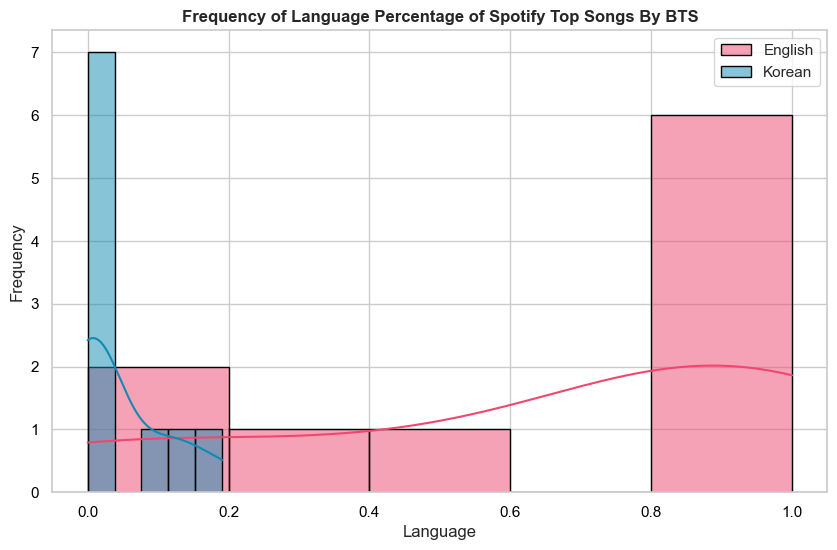

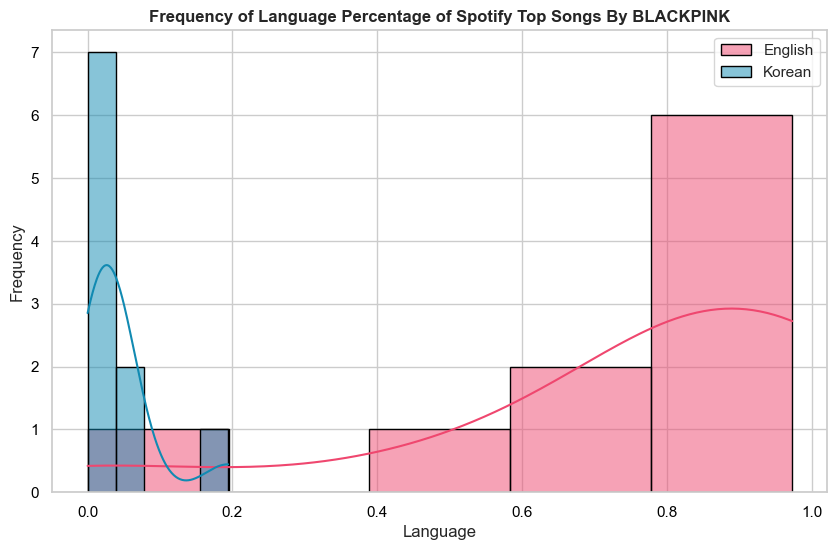

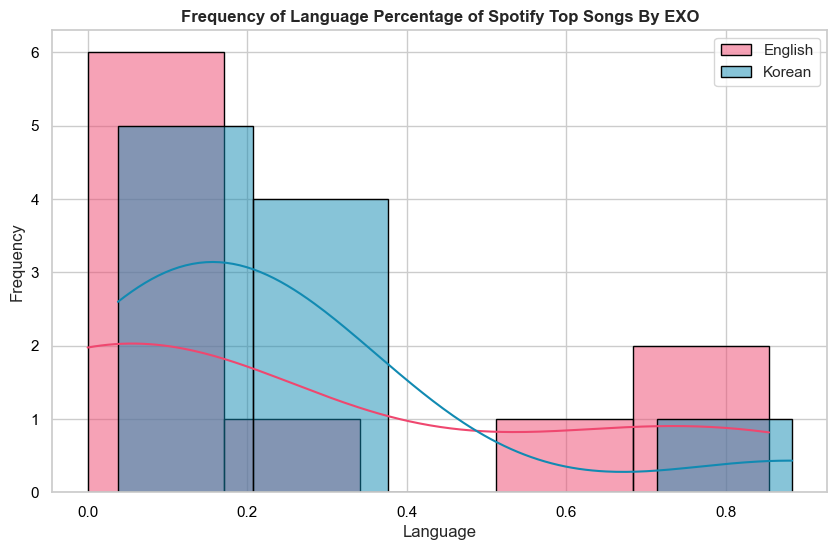

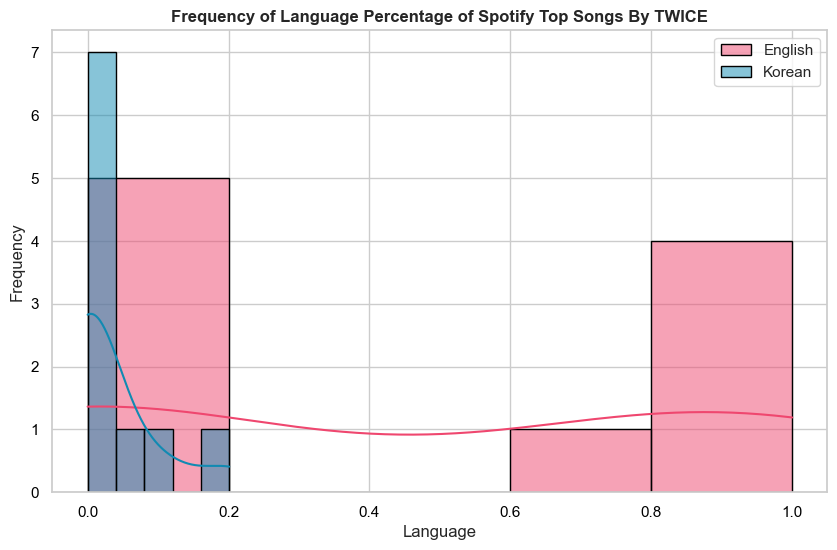

In [28]:
artists = ['bts','blackpink','exo','twice']
for artist in artists:
    tracks_hist(artist)